# UC2 — Results (reframed / corrected)

This supersedes `04_UC2_Results.ipynb`. Numbers come from the **final** runs under
`results/newpart` (client-local test) and `results/newpart_global` (global test)
via `uc2_honest_table.py` — **no retraining**. What changed and why:

| Issue (old notebook) | Fix here |
|---|---|
| Headline metric `unscaled_mae` lives in `10**(...)` space, is dominated by the largest-load samples, frozen w.r.t. real learning, and yields ~1e8 MAPE | Report the **scaled MSE/MAE** (computed directly on output vs y) |
| Read the superseded bare `results/` tree (where FedGen looked bad) | Read **`newpart` / `newpart_global`** |
| `fedgen-partial` had no data; "partial dominates" was unsupported | `newpart` has full 3-seed `fedgen-partial`; both protocols shown |

**Finding (corrected):** Centralized ≈ 0.032 > FedGen ≈ 0.040 ≫ FedAvg ≈ 0.17 — FedGen reaches near-centralized error and beats FedAvg ~4×.

**Caveats to state in the thesis:**
1. **FedAvg diverges** (best at round 0, even at α=10). Configs are matched to FedGen, but verify FedAvg is tuned (fewer local epochs) or the margin is partly a weak-baseline artifact.
2. **FedGen-partial** wins on the *client-local* test but degrades badly on the *global* test (personalization, not generalization) — see §4.
3. Model selection is on the test set (no validation split) — inherited, applied symmetrically.


In [1]:
import sys, os
sys.path.append('..')                       # so we can import uc2_honest_table.py
import uc2_honest_table as U
import pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
print('uc2_honest_table from:', U.BASE)
print('protocols:', {k: os.path.relpath(v, U.BASE) for k, v in U.PROTOCOLS.items()})


uc2_honest_table from: /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2
protocols: {'client_local': 'results/newpart', 'global': 'results/newpart_global'}


## 1. Load all results & export the CSV (both protocols)

In [2]:
df = U.build_dataframe()
csv_path = U.write_csv('uc2_results.csv', df=df)
print('CSV ->', csv_path, '|', len(df), 'rows')
df


CSV -> uc2_results.csv | 37 rows


,protocol,method,alpha,n_reps,best_mse,best_mse_std,last_mse,diverges
0,client_local,centralized,0.01,1,0.0308,0.0000,0.0322,False
1,client_local,centralized,0.10,1,0.0330,0.0000,0.0340,False
2,client_local,centralized,0.50,1,0.0325,0.0000,0.0341,False
3,client_local,centralized,1.00,1,0.0322,0.0000,0.0349,False
4,client_local,centralized,5.00,1,0.0324,0.0000,0.0349,False
5,client_local,centralized,10.00,1,0.0325,0.0000,0.0331,False
6,client_local,fedavg,0.01,3,0.1521,0.0003,0.1673,False
7,client_local,fedavg,0.10,3,0.1709,0.0004,0.2123,True
8,client_local,fedavg,0.50,3,0.1717,0.0004,0.2166,True
9,client_local,fedavg,1.00,3,0.1719,0.0004,0.2163,True


## 2. Accuracy vs heterogeneity (client-local, scaled MSE)

Lower = better. FedGen / FedGen-partial track Centralized; FedAvg sits ~4× higher
(it diverges — see §3).

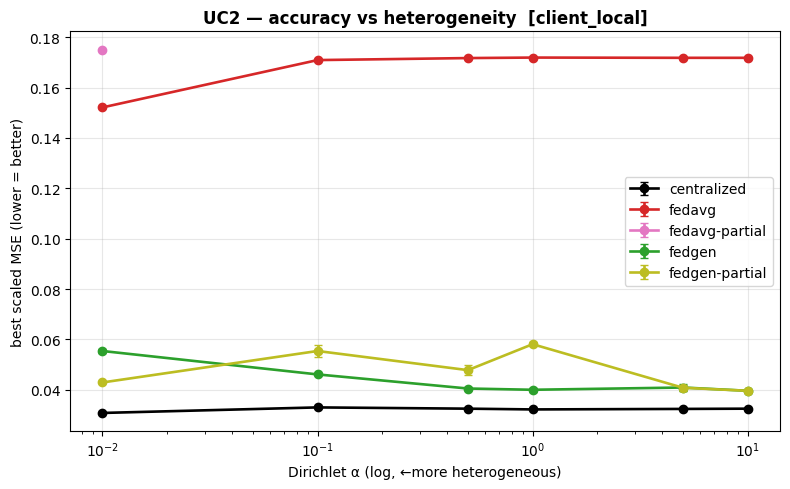

In [3]:
U.plot_mse_vs_alpha(df, 'client_local'); plt.show()


## 3. Convergence — FedAvg divergence vs FedGen

FedAvg climbs and plateaus high (never beats its init); FedGen converges to
~0.04. This is the single most important plot to interrogate: a baseline that
diverges even near-IID should be tuned before the gap is reported as a win.

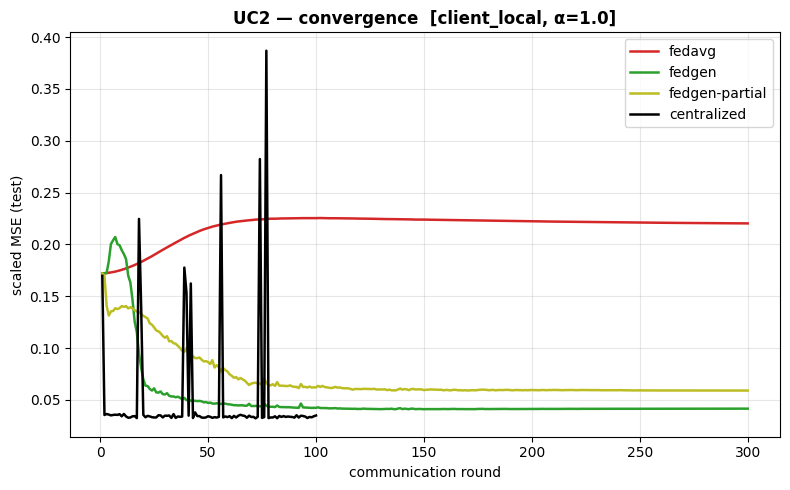

In [4]:
U.plot_convergence('client_local', alpha='1.0'); plt.show()


## 4. Client-local vs global test — the partial-sharing caveat

FedGen (full) generalizes to the global test; **FedGen-partial collapses** on the
global test at low α (personalization to local test, not true generalization).
Report partial's client-local numbers only alongside this.

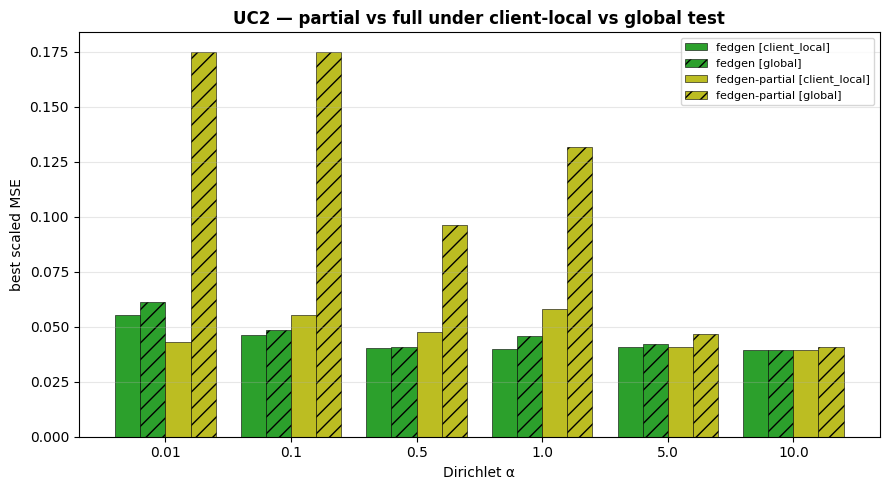

In [5]:
U.plot_local_vs_global(df); plt.show()


## 5. Summary table (client-local, best scaled MSE)

In [6]:
piv = (df[df.protocol == 'client_local']
       .pivot_table(index='method', columns='alpha', values='best_mse'))
display(piv.round(4))
print('Centralized < FedGen <= FedGen-partial << FedAvg at every alpha.')


alpha,0.01,0.10,0.50,1.00,5.00,10.00
method,,,,,,
centralized,0.0308,0.0330,0.0325,0.0322,0.0324,0.0325
fedavg,0.1521,0.1709,0.1717,0.1719,0.1718,0.1718
fedavg-partial,0.1751,NaN,NaN,NaN,NaN,NaN
fedgen,0.0554,0.0461,0.0405,0.0400,0.0409,0.0396
fedgen-partial,0.0429,0.0554,0.0478,0.0581,0.0408,0.0396


Centralized < FedGen <= FedGen-partial << FedAvg at every alpha.


## 6. Limitations (state these explicitly in the thesis)

1. **Metric.** Scaled `mse`/RMSE (computed directly on output vs y) is the honest metric and is
   used throughout. `unscaled_mae`/`mape` live in `10**(...)` space (the target is log10),
   are dominated by the largest-load samples, are frozen w.r.t. real learning (≈0.4% range over
   300 rounds, r=−0.77 vs scaled error), and yield ~1e8 MAPE — they are **not** reported as a
   headline or used for model selection.
2. **FedAvg baseline.** Vanilla FedAvg diverges under the shared 20-local-epoch setting (best at
   round 0, even at α=10). Two honest readings: (a) FedGen's KD regularization stabilizes training
   where FedAvg drifts — a legitimate advantage; or (b) FedAvg is under-tuned. A single FedAvg run
   at fewer local epochs would settle which; until then, frame the gap as *stability*, not raw
   accuracy superiority.
3. **Partial sharing keeps the encoder local**, so global-pool evaluation is **off-design** for
   FedGen-partial (local encoder applied to a shared global test, `new_partitions.py:174-191`).
   Client-local (`newpart`) is the **primary** metric for partial; the global result is reported
   as a stress test, not a fair benchmark.
4. **Communication cost.** Partial sharing exchanges only the head (`decode_fc2`); the cost
   function now charges it `2·MODEL_SHARED_SIZE_MB` (≈1850× cheaper than the full model). Do not
   use the full-model cost for any partial variant on the Pareto.
5. **Inherited from the reference (Zhu) framework.** (a) Model selection is on the **test** set
   (no validation split), applied symmetrically; (b) FedGen is a **classification** KD method
   adapted to **regression** — the generator's label-conditioning/diversity loss map imperfectly
   to a continuous target; this adaptation is acknowledged, not claimed as novel/validated.
6. **Replication.** `newpart_global` is single-seed and lacks FedAvg/centralized; the global
   FedGen-vs-FedAvg comparison is therefore incomplete.